In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False

In [2]:
visual = pd.read_csv('../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
visual.head(2)

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010


In [3]:
visual.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '지역내총생산(십억원)',
       '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [4]:
# 2차 변수 분류
# 종속변수
y_cols = visual[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = visual[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도']]

# 모델링용 독립변수
x_cols_control = visual[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '통계방식변경']]


# 통제변수
meta_cols = visual[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = visual[['연도', '행정구역']]

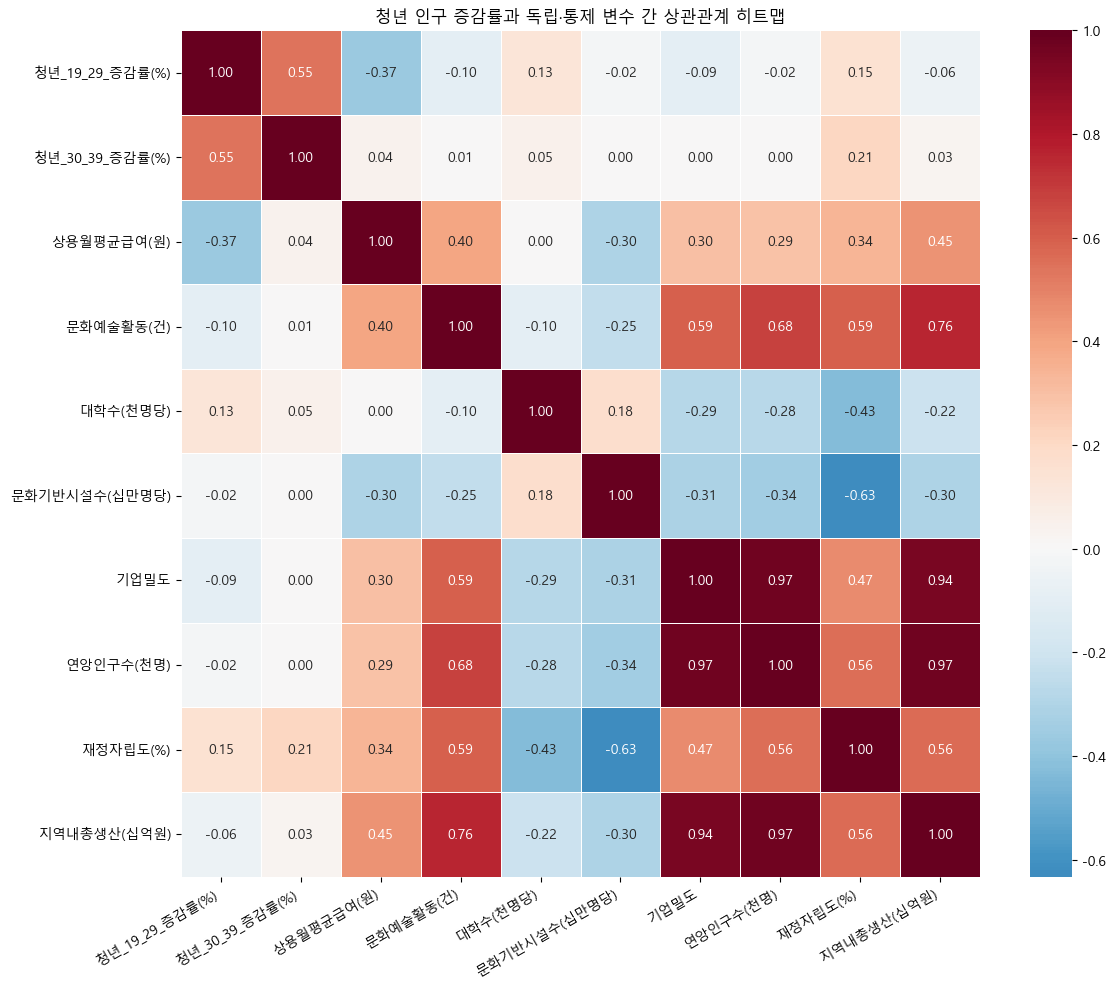

In [5]:
heatmap_cols = [
    '청년_19_29_증감률(%)',
    '청년_30_39_증감률(%)',
    '상용월평균급여(원)',
    '문화예술활동(건)',
    '대학수(천명당)',
    '문화기반시설수(십만명당)',
    '기업밀도',
    '연앙인구수(천명)',
    '재정자립도(%)',
    '지역내총생산(십억원)'
]

corr = visual[heatmap_cols].corr()

plt.figure(figsize=(12,10))
sb.heatmap(
    corr,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.title('청년 인구 증감률과 독립·통제 변수 간 상관관계 히트맵')
plt.tight_layout()
plt.show()


#### 20대 극단값 지역 판별

In [6]:
EXTREME_THRESHOLD = 10

extreme_regions_20 = (
    visual.groupby("행정구역")["청년_19_29_증감률(%)"]
    .apply(lambda x: x.abs().max() >= EXTREME_THRESHOLD)
)
extreme_regions_20 = extreme_regions_20[extreme_regions_20].index.tolist()


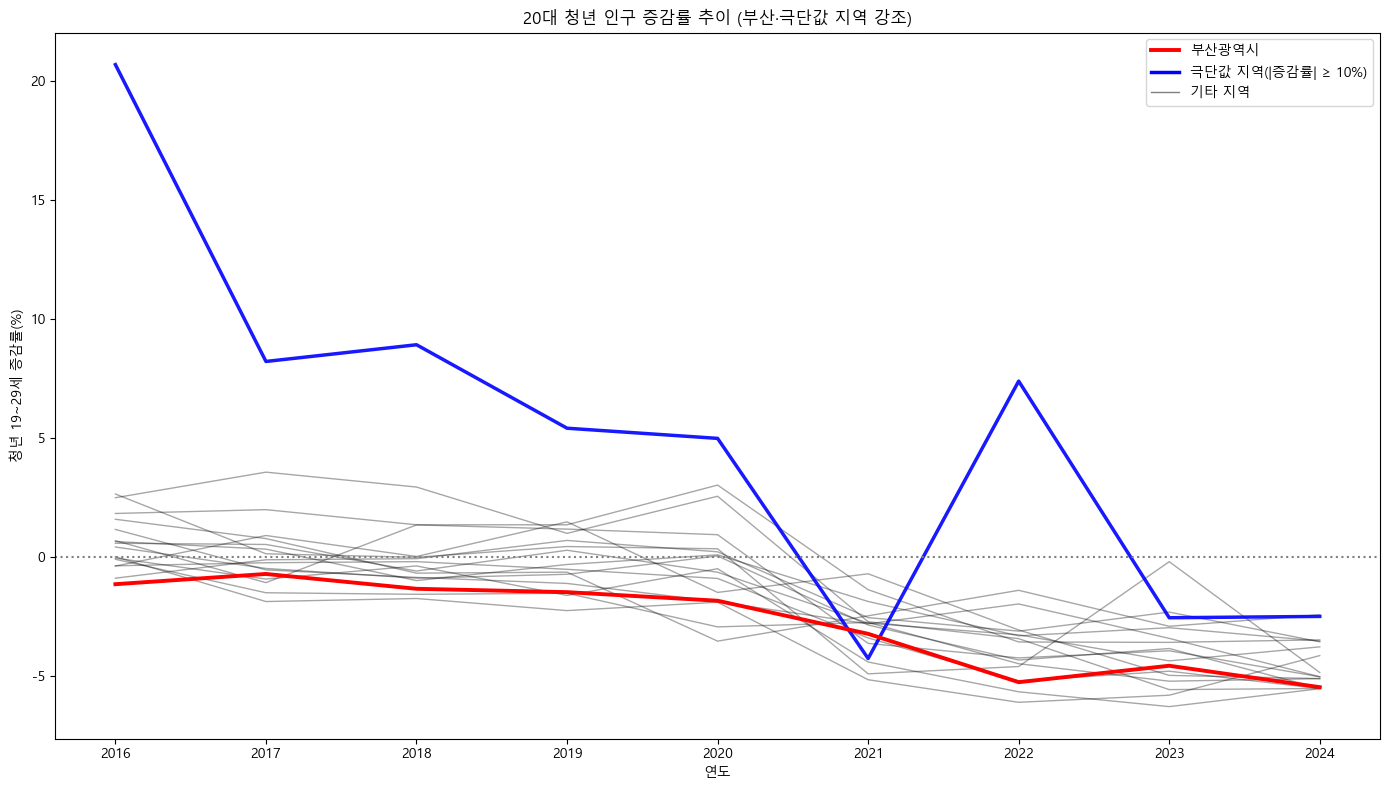

20대 극단 지역 (|증감률| ≥ 10%)
['세종특별자치시']


In [7]:
plt.figure(figsize=(14,8))

for region in visual["행정구역"].unique():
    tmp = visual[visual["행정구역"] == region].sort_values("연도")

    if region == "부산광역시":
        color, lw, alpha, z = "red", 2.8, 1.0, 3
    elif region in extreme_regions_20:
        color, lw, alpha, z = "blue", 2.5, 0.9, 2
    else:
        color, lw, alpha, z = "black", 1, 0.35, 1

    plt.plot(
        tmp["연도"],
        tmp["청년_19_29_증감률(%)"],
        color=color, linewidth=lw, alpha=alpha, zorder=z
    )

plt.axhline(0, linestyle=":", color="gray")
plt.xlabel("연도")
plt.ylabel("청년 19~29세 증감률(%)")
plt.title("20대 청년 인구 증감률 추이 (부산·극단값 지역 강조)")

plt.plot([], [], color="red", lw=2.8, label="부산광역시")
plt.plot([], [], color="blue", lw=2.5, label="극단값 지역(|증감률| ≥ 10%)")
plt.plot([], [], color="black", lw=1, alpha=0.5, label="기타 지역")
plt.legend()

plt.tight_layout()
plt.show()

print("20대 극단 지역 (|증감률| ≥ 10%)")
print(extreme_regions_20)


#### 30대 극단값 지역 판별

In [8]:
extreme_regions_30 = (
    visual.groupby("행정구역")["청년_30_39_증감률(%)"]
    .apply(lambda x: x.abs().max() >= EXTREME_THRESHOLD)
)
extreme_regions_30 = extreme_regions_30[extreme_regions_30].index.tolist()


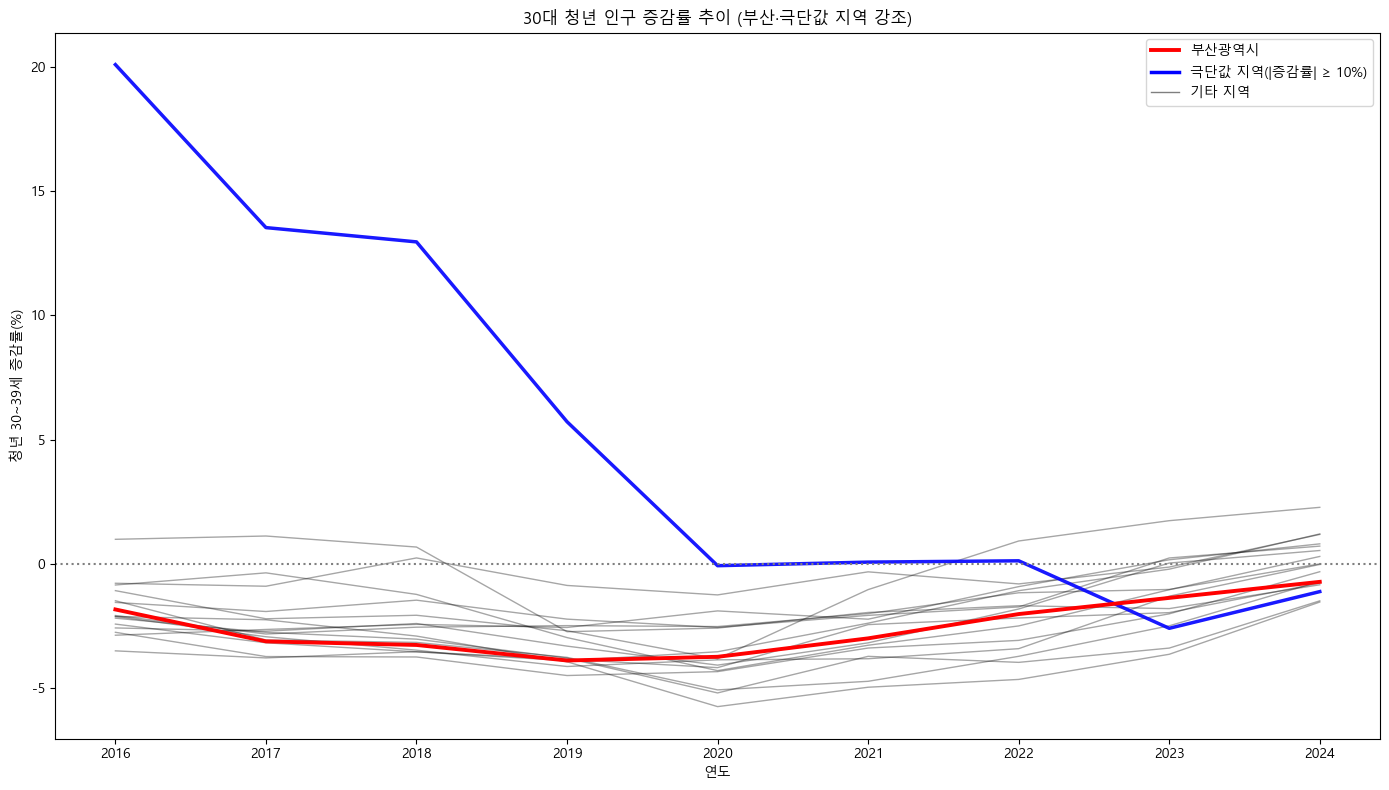

30대 극단 지역 (|증감률| ≥ 10%)
['세종특별자치시']


In [9]:
plt.figure(figsize=(14,8))

for region in visual["행정구역"].unique():
    tmp = visual[visual["행정구역"] == region].sort_values("연도")

    if region == "부산광역시":
        color, lw, alpha, z = "red", 2.8, 1.0, 3
    elif region in extreme_regions_30:
        color, lw, alpha, z = "blue", 2.5, 0.9, 2
    else:
        color, lw, alpha, z = "black", 1, 0.35, 1

    plt.plot(
        tmp["연도"],
        tmp["청년_30_39_증감률(%)"],
        color=color, linewidth=lw, alpha=alpha, zorder=z
    )

plt.axhline(0, linestyle=":", color="gray")
plt.xlabel("연도")
plt.ylabel("청년 30~39세 증감률(%)")
plt.title("30대 청년 인구 증감률 추이 (부산·극단값 지역 강조)")

plt.plot([], [], color="red", lw=2.8, label="부산광역시")
plt.plot([], [], color="blue", lw=2.5, label="극단값 지역(|증감률| ≥ 10%)")
plt.plot([], [], color="black", lw=1, alpha=0.5, label="기타 지역")
plt.legend()

plt.tight_layout()
plt.show()

print("30대 극단 지역 (|증감률| ≥ 10%)")
print(extreme_regions_30)


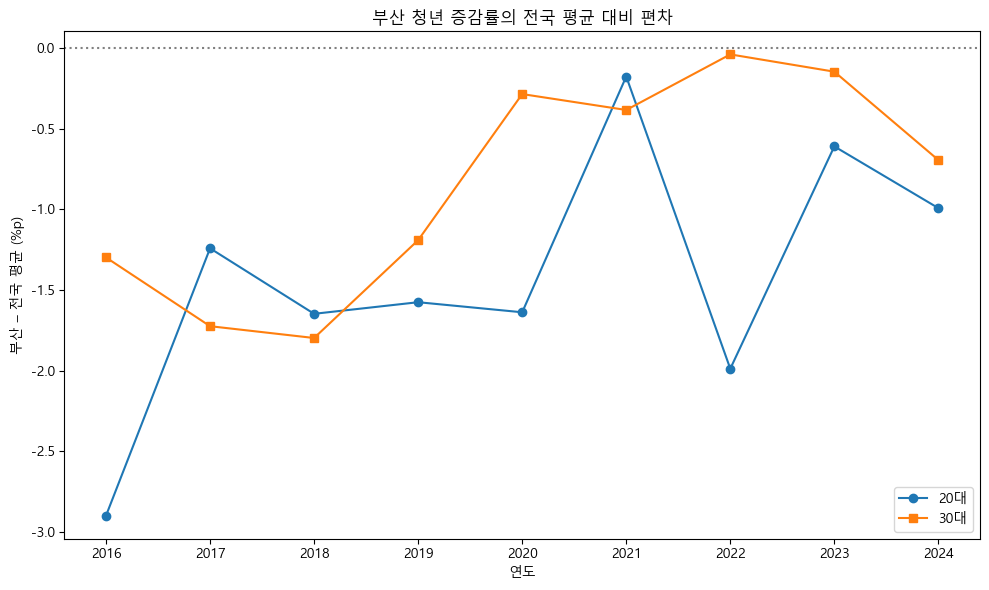

In [10]:
# 전국 평균
avg = (
    visual.groupby("연도")[["청년_19_29_증감률(%)","청년_30_39_증감률(%)"]]
    .mean()
    .reset_index()
)

# 부산
busan = visual[visual["행정구역"]=="부산광역시"].sort_values("연도")

# 편차 계산
diff = avg.copy()
diff["20대_부산-전국"] = busan["청년_19_29_증감률(%)"].values - avg["청년_19_29_증감률(%)"]
diff["30대_부산-전국"] = busan["청년_30_39_증감률(%)"].values - avg["청년_30_39_증감률(%)"]

plt.figure(figsize=(10,6))
plt.plot(diff["연도"], diff["20대_부산-전국"], marker="o", label="20대")
plt.plot(diff["연도"], diff["30대_부산-전국"], marker="s", label="30대")
plt.axhline(0, linestyle=":", color="gray")
plt.title("부산 청년 증감률의 전국 평균 대비 편차")
plt.xlabel("연도")
plt.ylabel("부산 – 전국 평균 (%p)")
plt.legend()
plt.tight_layout()
plt.show()
